# 14 Mode and Rail Context Analysis

## Purpose

This notebook builds on the service-efficiency dataset created in Notebook 13.

The original goal was to compare bus routes directly with METRORail lines. During exploration, the METRO ridership reports showed that local bus routes include productivity metrics such as boardings per revenue hour and boardings per revenue mile, while the rail section is reported at the station level rather than with directly comparable route-level productivity metrics.

Because of that data structure, this notebook focuses on identifying high-performing bus corridors and placing them in the broader context of future higher-capacity transit investment.

## Research Question

Which METRO corridors show the strongest combination of ridership demand and service productivity?

## Inputs

- `data/processed/route_efficiency_summary.csv`
- `data/raw/metro_gtfs/merged/routes.txt`

## Outputs

- Productivity rankings for METRO routes
- Identification of high-ridership, high-productivity corridors
- Context for future BRT or rail expansion analysis

## Why This Matters

A route with the highest ridership is not always the most efficient route. Transit agencies also care about how many riders are generated per hour or mile of service. These productivity measures help identify corridors where additional investment may produce strong public return.


## 1. Import Libraries

Import the libraries used for route productivity analysis and visualization.

In [2]:
import pandas as pd

service_efficiency = pd.read_csv(
    "../data/processed/service_efficiency_all_months.csv"
)

print(service_efficiency.shape)

service_efficiency.head()

(528, 13)


,route_id,route_name,weekday_avg_boardings,weekday_boardings_per_revenue_hour,weekday_boardings_per_revenue_mile,saturday_avg_boardings,saturday_boardings_per_revenue_hour,saturday_boardings_per_revenue_mile,sunday_avg_boardings,sunday_boardings_per_revenue_hour,sunday_boardings_per_revenue_mile,month,source_pdf
0,2,Bellaire,7590,31.56,2.88,5995,30.60,2.71,4915,25.09,2.22,October 2024,RS17348_October 2024 ridership report
1,3,Langley / Little York,2262,18.62,1.42,1869,15.46,1.17,1437,11.89,0.90,October 2024,RS17348_October 2024 ridership report
2,4,Beechnut,8743,27.20,2.17,5462,23.09,1.69,4231,17.89,1.31,October 2024,RS17348_October 2024 ridership report
3,5,Southmore,1265,18.57,1.58,621,12.39,0.91,564,11.25,0.83,October 2024,RS17348_October 2024 ridership report
4,6,Jensen / Greens,3895,20.40,1.40,2661,19.40,1.26,2262,16.49,1.07,October 2024,RS17348_October 2024 ridership report


## Supporting Analysis

This step supports the route productivity and mode-context analysis.

In [4]:
route_efficiency_summary = (
    service_efficiency
    .groupby(
        ["route_id", "route_name"],
        as_index=False
    )
    .agg(
        avg_weekday_boardings=(
            "weekday_avg_boardings",
            "mean"
        ),
        avg_boardings_per_revenue_hour=(
            "weekday_boardings_per_revenue_hour",
            "mean"
        ),
        avg_boardings_per_revenue_mile=(
            "weekday_boardings_per_revenue_mile",
            "mean"
        ),
        avg_saturday_boardings=(
            "saturday_avg_boardings",
            "mean"
        ),
        avg_sunday_boardings=(
            "sunday_avg_boardings",
            "mean"
        ),
        months_observed=(
            "month",
            "count"
        )
    )
)

route_efficiency_summary.head()

,route_id,route_name,avg_weekday_boardings,avg_boardings_per_revenue_hour,avg_boardings_per_revenue_mile,avg_saturday_boardings,avg_sunday_boardings,months_observed
0,2,Bellaire,7185.166667,29.880000,2.730000,5446.333333,4390.583333,12
1,3,Langley / Little York,2156.250000,16.979167,1.304167,1740.250000,1465.333333,12
2,4,Beechnut,8093.416667,25.177500,2.008333,5038.583333,4109.750000,12
3,5,Southmore,1195.833333,17.502500,1.488333,697.416667,537.583333,12
4,6,Jensen / Greens,3836.166667,20.087500,1.374167,2808.833333,2283.250000,12


## 2. Highest Ridership Routes

Identify the routes with the highest average weekday boardings. These routes represent the largest passenger markets in the network.

In [7]:
top_ridership = route_efficiency_summary.sort_values(
    "avg_weekday_boardings",
    ascending=False
).head(20)

top_ridership

,route_id,route_name,avg_weekday_boardings,avg_boardings_per_revenue_hour,avg_boardings_per_revenue_mile,avg_saturday_boardings,avg_sunday_boardings,months_observed
2,4,Beechnut,8093.416667,25.177500,2.008333,5038.583333,4109.750000,12
0,2,Bellaire,7185.166667,29.880000,2.730000,5446.333333,4390.583333,12
28,46,Gessner,7090.750000,32.541667,2.847500,5446.333333,4440.833333,12
13,25,Richmond,6758.083333,23.804167,2.052500,4855.250000,4033.750000,12
42,65,Bissonnet,6009.833333,27.970000,2.454167,3902.083333,3122.916667,12
35,54,Scott,5823.250000,27.473333,2.264167,4020.666667,3288.333333,12
36,56,Airline / Montrose,5371.750000,18.508333,1.599167,4253.750000,4020.750000,12
40,63,Fondren,4549.250000,34.294167,3.359167,3308.750000,2654.000000,12
27,45,Tidwell,4489.500000,22.055833,1.652500,2872.333333,2457.000000,12
24,40,Telephone / Heights,3905.166667,18.866667,1.518333,2771.166667,2378.333333,12


## 3. Most Productive Routes per Revenue Hour

Boardings per revenue hour measures how many riders are generated for each hour of service provided.

In [8]:
top_productive = route_efficiency_summary.sort_values(
    "avg_boardings_per_revenue_hour",
    ascending=False
).head(20)

top_productive

,route_id,route_name,avg_weekday_boardings,avg_boardings_per_revenue_hour,avg_boardings_per_revenue_mile,avg_saturday_boardings,avg_sunday_boardings,months_observed
6,8,West Bellfort,3361.083333,35.090000,2.678333,2256.000000,1851.500000,12
40,63,Fondren,4549.250000,34.294167,3.359167,3308.750000,2654.000000,12
28,46,Gessner,7090.750000,32.541667,2.847500,5446.333333,4440.833333,12
0,2,Bellaire,7185.166667,29.880000,2.730000,5446.333333,4390.583333,12
42,65,Bissonnet,6009.833333,27.970000,2.454167,3902.083333,3122.916667,12
35,54,Scott,5823.250000,27.473333,2.264167,4020.666667,3288.333333,12
2,4,Beechnut,8093.416667,25.177500,2.008333,5038.583333,4109.750000,12
29,47,Hillcroft,3761.833333,24.502500,2.345000,2326.416667,1947.666667,12
13,25,Richmond,6758.083333,23.804167,2.052500,4855.250000,4033.750000,12
39,60,Cambridge,1543.833333,23.771667,2.655833,697.083333,601.833333,12


## 4. Import Libraries

Import the libraries used for route productivity analysis and visualization.

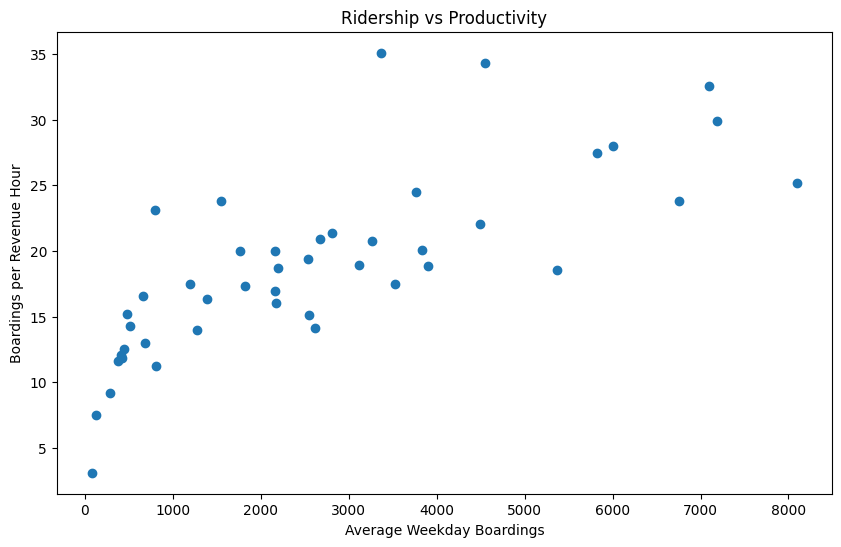

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.scatter(
    route_efficiency_summary["avg_weekday_boardings"],
    route_efficiency_summary["avg_boardings_per_revenue_hour"]
)

plt.xlabel("Average Weekday Boardings")
plt.ylabel("Boardings per Revenue Hour")
plt.title("Ridership vs Productivity")

plt.show()

## Supporting Analysis

This step supports the route productivity and mode-context analysis.

In [6]:
print(
    route_efficiency_summary.shape
)

print(
    route_efficiency_summary["months_observed"].value_counts()
)

(44, 8)
months_observed
12    44
Name: count, dtype: int64


## Key Interpretation

The ridership report structure does not support a perfect apples-to-apples comparison between bus route productivity and rail productivity.

Local bus routes include route-level boardings per revenue hour and boardings per revenue mile. Rail data appears in the reports as station-level boardings, which is useful for understanding rail demand geography but not directly comparable to bus route-level productivity.

For that reason, this notebook treats high-performing bus corridors as candidates for future higher-capacity transit analysis rather than forcing an invalid direct comparison.

## Summary

This notebook identifies METRO corridors that perform strongly on ridership and operational productivity.

The strongest candidates are routes that combine:

- High average weekday boardings
- High boardings per revenue hour
- High boardings per revenue mile

These corridors provide a defensible starting point for future accessibility, equity, BRT, and rail-expansion ROI analysis.
